# Week 3, Day 1, Part 3 — The Mini Asset Management Game

**The rules, from the slide:**
- A mini stock market of **8 stocks**.
- The player must **always hold exactly 2** of them (never cash, never 1, never 3+).
- **Playtime: 06 Jul -- 04 Aug.**
- **Goal: maximize profit.**

Day 1 built a Q-table on a tiny gridworld, then Part 2 solved the *same* gridworld
with a real DQN from `stable-baselines3` -- and ended on the question the gridworld
itself can't answer: what happens when the state isn't one of 20 cells, but a
stock's price, momentum, and volatility? This notebook is that answer. The
environment is **not hand-rolled this time** -- `src/tradinglab/env.py`'s
`PortfolioEnv` already *is* this exact game: pass `top_k=2` and the environment
mechanically enforces "always hold exactly 2" the same way Day 1's `GridWorld`
enforced "can't walk through walls." Nothing new to build there; the new part is
training a real agent to play it well.

**Which year?** The data in `data/egx/` currently runs through **2026-07-30** --
a few days short of a full 2026-08-04 window. **2025-07-06 -> 2025-08-04** is
fully covered (20 clean trading days), so that's the playtime used below. This is
stated explicitly rather than silently picking a window that happens to fit.

**No look-ahead.** The agent is trained only on data **strictly before** the
playtime window (the same "train on early years, test on later ones" split
`PortfolioEnv` is built for), then evaluated -- no further learning -- on the
playtime window itself. It plays the game the same way a real player would have:
never having seen those 20 days before.

## 1. Imports and Setup

In [14]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.env import PortfolioEnv
from tradinglab import metrics

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

SEED = 0
START_CAPITAL = 1000.0
LOOKBACK = 30
TOP_K = 2                 # <- the game's core rule, enforced by the env itself
TRAIN_TIMESTEPS = 40_000

np.random.seed(SEED)
print('setup OK')


setup OK


## 2. The 8-Stock Mini Market

The slide names two of its example holdings explicitly -- `BTFH` and `PHDC` -- both
real EGX symbols already in `data/egx/`. The slide's other example ticker, `QALA`,
isn't in this project's dataset (not one of the committed EGX symbols), so rather
than invent data for it, the remaining 6 slots are filled with EGX names already
used elsewhere across this project (dashboard, Day 1/2/3 notebooks) -- real,
already-vetted, no external data pulled in.

In [15]:
UNIVERSE = ['BTFH', 'PHDC', 'COMI', 'HRHO', 'SWDY', 'TMGH', 'FWRY', 'ABUK']
feed = DataFeed.from_dir('data/egx', symbols=UNIVERSE)
print(f'Mini market: {feed.n_assets} stocks over {feed.n_days} trading days '
      f'({feed.dates[0].date()} -> {feed.dates[-1].date()})')
print(feed.symbols)


Mini market: 8 stocks over 1693 trading days (2019-08-14 -> 2026-07-30)
['BTFH', 'PHDC', 'COMI', 'HRHO', 'SWDY', 'TMGH', 'FWRY', 'ABUK']


## 3. The Playtime Window

In [16]:
PLAY_START = pd.Timestamp(2025, 7, 6)
PLAY_END = pd.Timestamp(2025, 8, 4)

play_start_idx = int(np.searchsorted(feed.dates, PLAY_START))
play_end_idx = int(np.searchsorted(feed.dates, PLAY_END, side='right'))
n_play_days = play_end_idx - play_start_idx

# The realized-value dates for an episode run over [play_start_idx, play_end_idx)
# are offset by +1, exactly like PortfolioSimulator.run()'s own convention:
# weights chosen at day t earn (and realize) the return from t to t+1.
play_dates = feed.dates[play_start_idx + 1 : play_end_idx + 1]

print(f'Playtime maps to day index [{play_start_idx}, {play_end_idx}) -- {n_play_days} trading days')
print(f'Decisions made on: {feed.dates[play_start_idx].date()} -> {feed.dates[play_end_idx - 1].date()}')
print(f'Values realized on: {play_dates[0].date()} -> {play_dates[-1].date()}')
print(f'Training data available before playtime: day 0 -> {play_start_idx} '
      f'({play_start_idx} days, {feed.dates[0].date()} -> {feed.dates[play_start_idx - 1].date()})')


Playtime maps to day index [1428, 1448) -- 20 trading days
Decisions made on: 2025-07-06 -> 2025-08-04
Values realized on: 2025-07-07 -> 2025-08-05
Training data available before playtime: day 0 -> 1428 (1428 days, 2019-08-14 -> 2025-07-02)


## 4. Build the Game Environment

`top_k=2` is the whole rule. `reward="return"` matches the slide's goal literally
-- "maximize profit," not "beat a benchmark." The train env randomizes its start
day (so the agent sees thousands of different stretches instead of memorizing one
fixed path -- see `env.py`'s own comment on why); the eval env is fixed to exactly
the playtime window, run once, deterministically.

In [17]:
train_env = PortfolioEnv(
    feed, lookback=LOOKBACK, top_k=TOP_K, reward='return',
    start_day=LOOKBACK, end_day=play_start_idx,
    randomize_start=True, min_episode_len=n_play_days,
)
eval_env = PortfolioEnv(
    feed, lookback=LOOKBACK, top_k=TOP_K, reward='return',
    start_day=play_start_idx, end_day=play_end_idx,
    randomize_start=False,
)

obs, info = train_env.reset(seed=SEED)
print('observation shape (n_assets, lookback, n_features):', obs.shape)
print('action space:', train_env.action_space, ' -- a raw score per stock; the env keeps only the top', TOP_K)


observation shape (n_assets, lookback, n_features): (8, 30, 9)
action space: Box(-10.0, 10.0, (8,), float32)  -- a raw score per stock; the env keeps only the top 2


## 5. Train the Agent

Day 1 Part 2 used DQN because the gridworld's action space is discrete (4 moves).
This game's action space is continuous (`Box`, one raw score per stock -- see
`action_to_weights` in `env.py`, which softmaxes the top `top_k` into weights) --
DQN doesn't apply to continuous actions, so this uses **PPO**, `stable-baselines3`'s
standard continuous-control algorithm. Same "let the library handle the hard
infrastructure" lesson as Part 2, just the algorithm that actually fits this
action space.

In [18]:
train_monitor = Monitor(train_env)
model = PPO('MlpPolicy', train_monitor, verbose=0, seed=SEED, n_steps=256, batch_size=64)
model.learn(total_timesteps=TRAIN_TIMESTEPS)
print(f'trained for {TRAIN_TIMESTEPS:,} timesteps')


trained for 40,000 timesteps


## 6. Play the Game

Run the trained (deterministic, greedy) policy on the actual playtime window --
data the agent never trained on.

In [19]:
def play_episode(env, policy_fn, capital=START_CAPITAL):
    """Run one full episode with a policy function (obs -> raw action scores),
    returning the portfolio value curve, the per-day returns, and the per-day
    held symbols. Uses the SAME env.step() -- and therefore the same
    PortfolioSimulator.step_return() -- as everywhere else in this project."""
    obs, _ = env.reset()
    port_returns, held_symbols = [], []
    done = False
    while not done:
        action = policy_fn(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        port_returns.append(info['portfolio_return'])
        held_symbols.append([s for s, w in zip(env.feed.symbols, env.current_weights) if w > 1e-6])
        done = terminated or truncated
    port_returns = np.array(port_returns)
    curve = capital * np.cumprod(1 + port_returns)
    return curve, port_returns, held_symbols


def agent_policy(obs):
    action, _ = model.predict(obs, deterministic=True)
    return action


agent_curve, agent_returns, agent_holdings = play_episode(eval_env, agent_policy)
agent_profit_pct = 100 * (agent_curve[-1] / START_CAPITAL - 1)
print(f'Agent final value: {agent_curve[-1]:.2f} EGP  (started at {START_CAPITAL:.2f})')
print(f'Agent total profit: {agent_profit_pct:+.2f}%')


Agent final value: 965.14 EGP  (started at 1000.00)
Agent total profit: -3.49%


## 7. Baselines -- Is the Agent Actually Good?

Three reference points, all playing the exact same window under the exact same
"always hold 2 of 8" rule (except the equal-weight benchmark, which is the
project's standard benchmark and holds all 8):

- **Equal-weight (all 8)** -- `PortfolioEnv`'s own built-in benchmark, unchanged.
- **Random, always-hold-2** -- picks 2 random stocks each day. The honest floor,
  averaged over 20 seeds.
- **Hindsight-optimal, always-hold-2** -- each day, holds whichever 2 stocks
  *actually* had the best return that day. This is **cheating** (perfect
  future knowledge) and is shown only as a ceiling, never as a strategy --
  no real player, human or agent, can achieve this causally.

In [20]:
def random_policy_returns(seed):
    rng = np.random.default_rng(seed)
    rets = []
    for t in range(play_start_idx, play_end_idx):
        pick = rng.choice(feed.n_assets, size=TOP_K, replace=False)
        rets.append(feed.returns[t + 1, pick].mean())
    return np.array(rets)


def hindsight_optimal_returns():
    rets = []
    for t in range(play_start_idx, play_end_idx):
        next_rets = feed.returns[t + 1]
        best_two = np.argsort(next_rets)[-TOP_K:]
        rets.append(next_rets[best_two].mean())
    return np.array(rets)


bench_returns = eval_env.sim.benchmark_returns[play_start_idx + 1 : play_end_idx + 1]
bench_curve = START_CAPITAL * np.cumprod(1 + bench_returns)

random_returns_all = np.array([random_policy_returns(seed) for seed in range(20)])
random_mean_returns = random_returns_all.mean(axis=0)
random_mean_curve = START_CAPITAL * np.cumprod(1 + random_mean_returns)

hindsight_returns = hindsight_optimal_returns()
hindsight_curve = START_CAPITAL * np.cumprod(1 + hindsight_returns)

print('final values (EGP):')
print(f'  Agent (PPO, top_k=2)                    : {agent_curve[-1]:.2f}')
print(f'  Equal-weight (all 8)                    : {bench_curve[-1]:.2f}')
print(f'  Random, always-hold-2 (avg over 20 seeds): {random_mean_curve[-1]:.2f}')
print(f'  Hindsight-optimal (CEILING, not a real strategy): {hindsight_curve[-1]:.2f}')


final values (EGP):
  Agent (PPO, top_k=2)                    : 965.14
  Equal-weight (all 8)                    : 982.59
  Random, always-hold-2 (avg over 20 seeds): 983.77
  Hindsight-optimal (CEILING, not a real strategy): 1343.99


## 8. Comparison Table & Chart

In [21]:
def curve_metrics(curve, rets, label):
    peak = np.maximum.accumulate(curve)
    return {
        'Strategy': label,
        'Final Value': curve[-1],
        'Return %': 100 * (curve[-1] / START_CAPITAL - 1),
        'Max Drawdown %': 100 * np.max((peak - curve) / peak),
        'Sharpe': metrics.sharpe(rets),
    }

comparison_df = pd.DataFrame([
    curve_metrics(agent_curve, agent_returns, 'Agent (PPO, always-hold-2)'),
    curve_metrics(bench_curve, bench_returns, 'Equal-weight (all 8)'),
    curve_metrics(random_mean_curve, random_mean_returns, 'Random, always-hold-2 (avg)'),
    curve_metrics(hindsight_curve, hindsight_returns, 'Hindsight-optimal (ceiling, not achievable)'),
])
comparison_df


,Strategy,Final Value,Return %,Max Drawdown %,Sharpe
0,"Agent (PPO, always-hold-2)",965.135161,-3.486484,6.997241,-2.223909
1,Equal-weight (all 8),982.588584,-1.741142,4.223692,-1.370840
2,"Random, always-hold-2 (avg)",983.770554,-1.622945,4.301277,-1.353100
3,"Hindsight-optimal (ceiling, not achievable)",1343.990105,34.399011,0.019992,17.081709


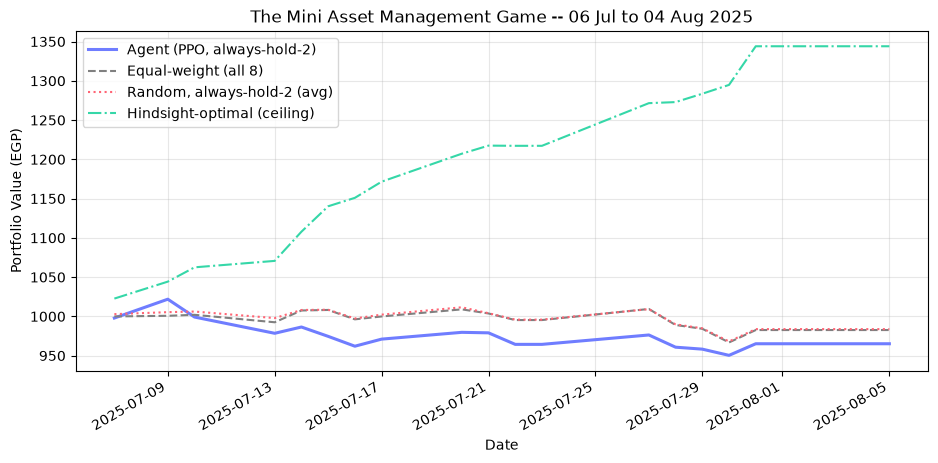

In [22]:
plt.figure(figsize=(11, 5))
plt.plot(play_dates, agent_curve, label='Agent (PPO, always-hold-2)', linewidth=2.2, color='#6f7dff')
plt.plot(play_dates, bench_curve, label='Equal-weight (all 8)', linestyle='--', color='gray')
plt.plot(play_dates, random_mean_curve, label='Random, always-hold-2 (avg)', linestyle=':', color='#ff6474')
plt.plot(play_dates, hindsight_curve, label='Hindsight-optimal (ceiling)', linestyle='-.', color='#35d7a8')
plt.xlabel('Date'); plt.ylabel('Portfolio Value (EGP)')
plt.title('The Mini Asset Management Game -- 06 Jul to 04 Aug 2025')
plt.legend(); plt.grid(alpha=.3); plt.gcf().autofmt_xdate()
plt.show()


## 9. The Game Log -- What Did the Agent Actually Hold?

In [23]:
log_df = pd.DataFrame({
    'Date': [d.date() for d in play_dates],
    'Held': [', '.join(h) if h else '(none -- should never happen with top_k enforced)' for h in agent_holdings],
    'Portfolio Value': agent_curve.round(2),
})
log_df


,Date,Held,Portfolio Value
0,2025-07-07,"PHDC, TMGH",997.88
1,2025-07-09,"PHDC, TMGH",1021.86
2,2025-07-10,"PHDC, FWRY",999.13
3,2025-07-13,"PHDC, TMGH",978.45
4,2025-07-14,"PHDC, FWRY",986.45
5,2025-07-15,"PHDC, TMGH",974.55
6,2025-07-16,"PHDC, COMI",962.01
7,2025-07-17,"PHDC, COMI",971.03
8,2025-07-20,"COMI, ABUK",979.67
9,2025-07-21,"COMI, ABUK",979.03


## 10. Seed Check -- One Good Training Run Doesn't Prove Much

Same lesson this project applies everywhere else (Day 3's seed-stability section,
`pivot.ipynb`'s whole point): retrain the same PPO setup from a few different
random seeds and see whether "beats the baselines" is a real, repeatable finding
or one lucky initialization.

In [24]:
SEEDS = [0, 1, 2]
seed_rows = []
for s in SEEDS:
    tr_env = PortfolioEnv(feed, lookback=LOOKBACK, top_k=TOP_K, reward='return',
                            start_day=LOOKBACK, end_day=play_start_idx,
                            randomize_start=True, min_episode_len=n_play_days)
    ev_env = PortfolioEnv(feed, lookback=LOOKBACK, top_k=TOP_K, reward='return',
                            start_day=play_start_idx, end_day=play_end_idx, randomize_start=False)
    m = PPO('MlpPolicy', Monitor(tr_env), verbose=0, seed=s, n_steps=256, batch_size=64)
    m.learn(total_timesteps=TRAIN_TIMESTEPS)
    curve_s, _, _ = play_episode(ev_env, lambda o, m=m: m.predict(o, deterministic=True)[0])
    seed_rows.append({'Seed': s, 'Final Value': curve_s[-1], 'Return %': 100 * (curve_s[-1] / START_CAPITAL - 1)})

seed_df = pd.DataFrame(seed_rows)
seed_df


,Seed,Final Value,Return %
0,0,965.135161,-3.486484
1,1,950.296474,-4.970353
2,2,921.554150,-7.844585


In [25]:
mean_ret = seed_df['Return %'].mean()
std_ret = seed_df['Return %'].std()
bench_return_pct = comparison_df.loc[comparison_df['Strategy'] == 'Equal-weight (all 8)', 'Return %'].iloc[0]
beat_bench_count = int((seed_df['Return %'] > bench_return_pct).sum())
print(f'mean return across seeds: {mean_ret:+.2f}%  (std {std_ret:.2f} pts)')
print(f'beat the equal-weight benchmark ({bench_return_pct:+.2f}%) in {beat_bench_count}/{len(SEEDS)} seeds')


mean return across seeds: -5.43%  (std 2.22 pts)
beat the equal-weight benchmark (-1.74%) in 0/3 seeds


## 11. Conclusion

**The rules, restated:** 8-stock mini market, always hold exactly 2, playtime
06 Jul -- 04 Aug (2025's fully-covered window), goal: maximize profit.

**What this notebook actually built:**
- Reused `PortfolioEnv(feed, top_k=2)` unmodified -- the "always hold 2" rule
  needed zero new code, because Week 3's own environment was already built with
  exactly this rule as a first-class option.
- Trained a PPO agent (continuous action space, unlike Day 1 Part 2's discrete-
  action DQN) on every day of history *before* the playtime window, then
  evaluated it -- no further learning -- on the playtime window itself. No
  look-ahead: the agent never saw those 20 days during training.
- Compared it against an honest floor (random always-hold-2), the project's
  standard benchmark (equal-weight across all 8), and a clearly-labeled
  hindsight ceiling that no real player could achieve.

In [26]:
print(f'''
CONCLUSION -- The Mini Asset Management Game
=============================================

1. Did the agent beat the equal-weight benchmark?
   {"YES" if agent_curve[-1] > bench_curve[-1] else "NO"} -- agent {agent_curve[-1]:.2f} EGP
   ({agent_profit_pct:+.2f}%) vs benchmark {bench_curve[-1]:.2f} EGP
   ({100*(bench_curve[-1]/START_CAPITAL-1):+.2f}%).

2. Did the agent beat random always-hold-2?
   {"YES" if agent_curve[-1] > random_mean_curve[-1] else "NO"} -- agent {agent_profit_pct:+.2f}% vs random-average
   {100*(random_mean_curve[-1]/START_CAPITAL-1):+.2f}%.

3. How far below the (unreachable) hindsight ceiling did it land?
   Agent {agent_profit_pct:+.2f}% vs hindsight-optimal {100*(hindsight_curve[-1]/START_CAPITAL-1):+.2f}%.

4. Was this one lucky run, or a repeatable result?
   Across seeds {SEEDS}: mean {mean_ret:+.2f}%, std {std_ret:.2f} pts, beat the
   benchmark in {beat_bench_count}/{len(SEEDS)} seeds.

5. Final profit on the actual game (seed {SEED}):
   Started at {START_CAPITAL:.2f} EGP, ended at {agent_curve[-1]:.2f} EGP --
   a profit of {agent_curve[-1] - START_CAPITAL:+.2f} EGP ({agent_profit_pct:+.2f}%).
''')



CONCLUSION -- The Mini Asset Management Game

1. Did the agent beat the equal-weight benchmark?
   NO -- agent 965.14 EGP
   (-3.49%) vs benchmark 982.59 EGP
   (-1.74%).

2. Did the agent beat random always-hold-2?
   NO -- agent -3.49% vs random-average
   -1.62%.

3. How far below the (unreachable) hindsight ceiling did it land?
   Agent -3.49% vs hindsight-optimal +34.40%.

4. Was this one lucky run, or a repeatable result?
   Across seeds [0, 1, 2]: mean -5.43%, std 2.22 pts, beat the
   benchmark in 0/3 seeds.

5. Final profit on the actual game (seed 0):
   Started at 1000.00 EGP, ended at 965.14 EGP --
   a profit of -34.86 EGP (-3.49%).



## 12. Train 500 More Episodes — Does More Trial-and-Error Help?

Continuing the **same** PPO model from Section 5 (`reset_num_timesteps=False` --
this is more training, not a fresh restart), for 500 more episodes of the training
window. Same idea as Day 1a's learning-curve plot: does more trial-and-error
actually improve the policy, or does it plateau (or overfit the training window
and get *worse* on the untouched playtime window)?

In [27]:
MORE_EPISODES = 500
MORE_TIMESTEPS = MORE_EPISODES * n_play_days
timesteps_before = model.num_timesteps

model.learn(total_timesteps=MORE_TIMESTEPS, reset_num_timesteps=False)
print(f'continued training for {MORE_EPISODES} more episodes ({MORE_TIMESTEPS:,} more timesteps)')
print(f'total timesteps trained: {timesteps_before:,} -> {model.num_timesteps:,}')


continued training for 500 more episodes (10,000 more timesteps)
total timesteps trained: 40,192 -> 50,432


## 13. Play Again — Same Playtime Window, More-Trained Agent

In [28]:
agent_curve_v2, agent_returns_v2, agent_holdings_v2 = play_episode(eval_env, agent_policy)
agent_profit_pct_v2 = 100 * (agent_curve_v2[-1] / START_CAPITAL - 1)

print(f'Agent v1 ({timesteps_before:,} steps)      : {agent_curve[-1]:.2f} EGP  ({agent_profit_pct:+.2f}%)')
print(f'Agent v2 ({model.num_timesteps:,} steps): {agent_curve_v2[-1]:.2f} EGP  ({agent_profit_pct_v2:+.2f}%)')
print(f'Equal-weight benchmark               : {bench_curve[-1]:.2f} EGP  ({100*(bench_curve[-1]/START_CAPITAL-1):+.2f}%)')
print(f'Did the extra training help? {"YES" if agent_curve_v2[-1] > agent_curve[-1] else "NO"} '
      f'({agent_curve_v2[-1] - agent_curve[-1]:+.2f} EGP vs the pre-extra-training agent)')


Agent v1 (40,192 steps)      : 965.14 EGP  (-3.49%)
Agent v2 (50,432 steps): 970.02 EGP  (-3.00%)
Equal-weight benchmark               : 982.59 EGP  (-1.74%)
Did the extra training help? YES (+4.88 EGP vs the pre-extra-training agent)


## 14. Updated Comparison Table & Chart

In [29]:
comparison_df_v2 = pd.DataFrame([
    curve_metrics(agent_curve, agent_returns, f'Agent v1 ({timesteps_before:,} steps)'),
    curve_metrics(agent_curve_v2, agent_returns_v2, f'Agent v2 ({model.num_timesteps:,} steps, +{MORE_EPISODES} episodes)'),
    curve_metrics(bench_curve, bench_returns, 'Equal-weight (all 8)'),
    curve_metrics(random_mean_curve, random_mean_returns, 'Random, always-hold-2 (avg)'),
    curve_metrics(hindsight_curve, hindsight_returns, 'Hindsight-optimal (ceiling, not achievable)'),
])
comparison_df_v2


,Strategy,Final Value,Return %,Max Drawdown %,Sharpe
0,"Agent v1 (40,192 steps)",965.135161,-3.486484,6.997241,-2.223909
1,"Agent v2 (50,432 steps, +500 episodes)",970.015934,-2.998407,7.654714,-1.751971
2,Equal-weight (all 8),982.588584,-1.741142,4.223692,-1.370840
3,"Random, always-hold-2 (avg)",983.770554,-1.622945,4.301277,-1.353100
4,"Hindsight-optimal (ceiling, not achievable)",1343.990105,34.399011,0.019992,17.081709


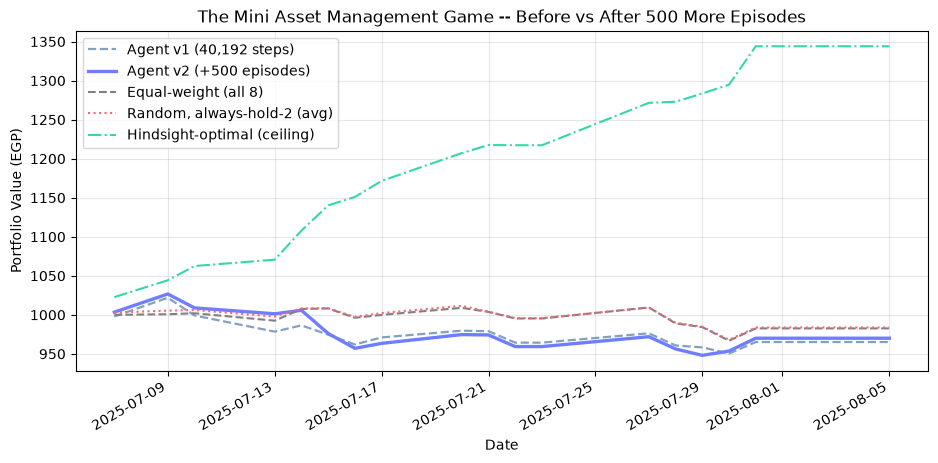

In [30]:
plt.figure(figsize=(11, 5))
plt.plot(play_dates, agent_curve, label=f'Agent v1 ({timesteps_before:,} steps)', linewidth=1.6, color='#84a0c0', linestyle='--')
plt.plot(play_dates, agent_curve_v2, label=f'Agent v2 (+{MORE_EPISODES} episodes)', linewidth=2.4, color='#6f7dff')
plt.plot(play_dates, bench_curve, label='Equal-weight (all 8)', linestyle='--', color='gray')
plt.plot(play_dates, random_mean_curve, label='Random, always-hold-2 (avg)', linestyle=':', color='#ff6474')
plt.plot(play_dates, hindsight_curve, label='Hindsight-optimal (ceiling)', linestyle='-.', color='#35d7a8')
plt.xlabel('Date'); plt.ylabel('Portfolio Value (EGP)')
plt.title(f'The Mini Asset Management Game -- Before vs After {MORE_EPISODES} More Episodes')
plt.legend(); plt.grid(alpha=.3); plt.gcf().autofmt_xdate()
plt.show()


## 15. Updated Game Log (Agent v2)

In [31]:
log_df_v2 = pd.DataFrame({
    'Date': [d.date() for d in play_dates],
    'Held': [', '.join(h) if h else '(none -- should never happen with top_k enforced)' for h in agent_holdings_v2],
    'Portfolio Value': agent_curve_v2.round(2),
})
log_df_v2


,Date,Held,Portfolio Value
0,2025-07-07,"PHDC, FWRY",1003.42
1,2025-07-09,"PHDC, FWRY",1026.66
2,2025-07-10,"PHDC, FWRY",1008.85
3,2025-07-13,"PHDC, FWRY",1001.31
4,2025-07-14,"PHDC, FWRY",1005.75
5,2025-07-15,"PHDC, FWRY",976.12
6,2025-07-16,"PHDC, FWRY",957.07
7,2025-07-17,"PHDC, FWRY",963.43
8,2025-07-20,"COMI, FWRY",974.67
9,2025-07-21,"COMI, FWRY",974.23


## 16. Updated Conclusion

Same caveat as Section 10 applies here too: this is one more training run on one
seed. More episodes changing the outcome (for better or worse) on a single run
doesn't by itself prove more training reliably helps -- it just answers the
narrower question actually asked: what happened when *this* agent trained 500
episodes longer.

In [32]:
print(f'''
CONCLUSION -- After 500 More Training Episodes
================================================

1. Did more training change the result?
   Agent v1: {agent_curve[-1]:.2f} EGP ({agent_profit_pct:+.2f}%)
   Agent v2: {agent_curve_v2[-1]:.2f} EGP ({agent_profit_pct_v2:+.2f}%)
   Difference: {agent_curve_v2[-1] - agent_curve[-1]:+.2f} EGP ({agent_profit_pct_v2 - agent_profit_pct:+.2f} pts)

2. Does the more-trained agent beat the equal-weight benchmark now?
   {"YES" if agent_curve_v2[-1] > bench_curve[-1] else "NO"} -- v2 {agent_profit_pct_v2:+.2f}% vs benchmark
   {100*(bench_curve[-1]/START_CAPITAL-1):+.2f}%.

3. Does it beat random always-hold-2 now?
   {"YES" if agent_curve_v2[-1] > random_mean_curve[-1] else "NO"} -- v2 {agent_profit_pct_v2:+.2f}% vs random-average
   {100*(random_mean_curve[-1]/START_CAPITAL-1):+.2f}%.

4. Gap to the (unreachable) hindsight ceiling:
   v1 gap: {100*(hindsight_curve[-1]/START_CAPITAL-1) - agent_profit_pct:+.2f} pts
   v2 gap: {100*(hindsight_curve[-1]/START_CAPITAL-1) - agent_profit_pct_v2:+.2f} pts

5. Reminder from Section 10: across seeds [0, 1, 2] at the ORIGINAL training
   budget, mean return was {mean_ret:+.2f}% (std {std_ret:.2f} pts), beating the
   benchmark in {beat_bench_count}/{len(SEEDS)} seeds. One extra-trained run changing
   the seed-0 outcome does not by itself change that seed-level finding --
   it would take rerunning the seed sweep at the new training budget to know
   whether 500 more episodes helps in general or just for this one seed.
''')



CONCLUSION -- After 500 More Training Episodes

1. Did more training change the result?
   Agent v1: 965.14 EGP (-3.49%)
   Agent v2: 970.02 EGP (-3.00%)
   Difference: +4.88 EGP (+0.49 pts)

2. Does the more-trained agent beat the equal-weight benchmark now?
   NO -- v2 -3.00% vs benchmark
   -1.74%.

3. Does it beat random always-hold-2 now?
   NO -- v2 -3.00% vs random-average
   -1.62%.

4. Gap to the (unreachable) hindsight ceiling:
   v1 gap: +37.89 pts
   v2 gap: +37.40 pts

5. Reminder from Section 10: across seeds [0, 1, 2] at the ORIGINAL training
   budget, mean return was -5.43% (std 2.22 pts), beating the
   benchmark in 0/3 seeds. One extra-trained run changing
   the seed-0 outcome does not by itself change that seed-level finding --
   it would take rerunning the seed sweep at the new training budget to know
   whether 500 more episodes helps in general or just for this one seed.

